### Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from typing import NamedTuple
import numpy as np
%matplotlib inline

### Basic Intuition

In [ ]:
# read the data
names = open("../names.txt", 'r').read().splitlines()
names[:8]

In [ ]:
len(names)

In [ ]:
# create the vocabulary
chars = sorted(list(set(''.join(names))))
stoi = {s:i for i, s in enumerate(chars, start=1)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
itos

In [ ]:
# build dataset
block_size = 3
X, Y = [],[]

for w in names[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '----->',itos[ix])
        context = context[1:] + [ix]

X, Y = torch.tensor(X), torch.tensor(Y)

In [ ]:
# (examples, block_size)
X[:5],Y[:5]

In [373]:
# lookup table C
g = torch.Generator().manual_seed(42)
C = torch.randn(size=(27, 2), generator=g)

In [374]:
dummy_encoding = F.one_hot(torch.tensor(5), num_classes=27).float()
assert (C[5] == (dummy_encoding @ C)).all()

In [ ]:
# encode the context again
X_enc = F.one_hot(X, num_classes=27).float()
X_enc.shape

In [ ]:
# get lookup values for multiple inputs
C[[5,6,7]]

In [ ]:
C[X].shape

In [ ]:
# get embedding (examples, block size, embedding size)
emb = C[X]
emb.shape

In [379]:
# build the model
g = torch.Generator().manual_seed(42)
W1 = torch.randn(size=(6, 100), generator=g)
b1 = torch.randn(100, generator=g)


In [ ]:
# get the embeddings for all the 32 examples and concatenate them so that we can get the shape of (examples, block_size * embedding_size)
# emb shape -> (examples, block_size, embedding_size)
torch.cat(torch.unbind(emb, dim=1), dim=1).shape

In [34]:
# check if element wise both the operations are equviavalent.
assert (torch.cat(torch.unbind(emb, 1), 1) == emb.view(32, -1)).all()

In [ ]:
# using the view method since its much more efficient
# in general -> we can view it as (examples, -1) the -1 makes it easy so we dont hard code things
h = torch.tanh(((emb.view(32,-1) @ W1) + b1))
h.shape

In [36]:
# output layer
g = torch.Generator().manual_seed(42)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)

In [ ]:
logits = ((h @ W2) + b2)
logits.shape

In [ ]:
probs = F.softmax(logits, dim = 1)

In [ ]:
F.cross_entropy(logits, Y)

### Putting it together

In [341]:
# HYPERPARAMS
BLOCK_SIZE = 3
EMBED_SIZE = 2
BOUNDARY_CHAR = "."
SEED_VAL = 42
BATCH_SIZE = 32

In [ ]:
# load the names
names = open("../names.txt").read().splitlines()
len(names), names[:8]

In [ ]:
# create the vocabulary
# get the unique characters in the names
unique_chars = sorted(list(set(''.join(names))))
unique_chars.insert(0, BOUNDARY_CHAR)
# create a mapping str -> int
stoi = {s: i for i , s in enumerate(unique_chars)}
# create the reverse mapping
itos = {i: s for s, i in stoi.items()}

len(unique_chars), stoi



In [ ]:
# create data set on the complete data set using the BLOCK_SIZE parameter
X, Y = [], []


for w in names:
    contex = [0] * BLOCK_SIZE
    for ch in w + BOUNDARY_CHAR:
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X, Y = torch.tensor(X), torch.tensor(Y)
X.shape, Y.shape

In [ ]:
# Create model architecture as defined below
# a lookup table that takes in the words (context) and embeds them into embed size vectors
# a neruon layer with 100 neurons that has the tanh actiavtion
# a output layer that has softmax at the end for probs


# generator object for reporoducible results
g = torch.Generator().manual_seed(SEED_VAL)


# lookup table we have len(unique_chars) unique characters (26 lower case alphabet + 1 boundary char)
C = torch.randn(size=(len(unique_chars), EMBED_SIZE), generator=g)


# the first layer contains W1 weights and b1 bias
# the shape of the W1 matrix will be (context_lenght or block_size * embed_dim, n_neurons)
# each neuron in the layer has a unique bias term so there will be n_neuron bias term
W1 = torch.randn(
    size = (
        BLOCK_SIZE * EMBED_SIZE,
        100
    ),
    generator=g
)

b1 = torch.randn(100)


# the output layer is a linear layer hence will contain its W matrix and b vector
# W2 will be of size -> (n_neurons_first_layer, n_unique) trying to model the probability for the next char given 27 characters and context
# b2 will be of size -> n_unique
W2 = torch.randn(
    size = (
        100,
        len(unique_chars)
    ),
    generator=g
)

b2 = torch.randn(
    len(unique_chars),
    generator=g
)


parameters = [C, W1,b1,W2,b2]

# add requires grad for all trainable parameters
for p in parameters:
    p.requires_grad = True

# C.shape -> (unique_chars, EMBED_SIZE)
# W1.shape -> (context_size * embed_dim, n_neurons_in_first_layer)
# b1.shape -> n_nuerons in first layer (each neuron has its own bias term)
C.shape, W1.shape, b1.shape, W2.shape, b2.shape

In [ ]:
# printing the numebr of parameters
sum(p.nelement() for p in parameters)

In [ ]:
# we index into the lookup table rater than one hot encode since its more easy
# also it allows to parallely embed the complete training set (or any set of input)

emb = C[X]

# shape -> (examples, context, embed)
# view shape -> efficient reshape of the tensors in emb so that we can do a dot product with the weights -> (examples, context_size * embed_size)
emb.shape, emb.view(len(X), -1).shape, W1.shape

In [ ]:
# get a good learning rate


# start with the low of 0.001 uptil 1.
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

lossi = []
lri = []


# complete training loop

for i in range(1000):
    
    # get mini batch
    ix = torch.randint(0, X.shape[0], size=(BATCH_SIZE,))


    # forward pass
    # embed the input contexts
    emb = C[X[ix]]

    # run the embeddings through the first layer

    h = torch.tanh((emb.view(-1, BLOCK_SIZE * EMBED_SIZE) @ W1) + b1)

    # get the logits from the output layer
    logits = (h @ W2) + b2

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass

    # zero out the gradients
    for p in parameters:
        p.grad = None



    # backprop
    loss.backward()

    lr = lrs[i]
    # update
    for p in parameters:
        p.data = p.data - lr * p.grad   

    # track stats
    lossi.append(loss.item())
    lri.append(lre[i].item())

print(f"{loss=:.4f}")



In [ ]:
plt.plot(lri, lossi)

In [350]:
# the lr with min loss
LEARNING_RATE = 10 ** lri[torch.argmin(torch.tensor(lossi)).item()]

In [ ]:
# Create model architecture as defined below
# a lookup table that takes in the words (context) and embeds them into embed size vectors
# a neruon layer with 100 neurons that has the tanh actiavtion
# a output layer that has softmax at the end for probs


# generator object for reporoducible results
g = torch.Generator().manual_seed(SEED_VAL)


# lookup table we have len(unique_chars) unique characters (26 lower case alphabet + 1 boundary char)
C = torch.randn(size=(len(unique_chars), EMBED_SIZE), generator=g)


# the first layer contains W1 weights and b1 bias
# the shape of the W1 matrix will be (context_lenght or block_size * embed_dim, n_neurons)
# each neuron in the layer has a unique bias term so there will be n_neuron bias term
W1 = torch.randn(
    size = (
        BLOCK_SIZE * EMBED_SIZE,
        100
    ),
    generator=g
)

b1 = torch.randn(100)


# the output layer is a linear layer hence will contain its W matrix and b vector
# W2 will be of size -> (n_neurons_first_layer, n_unique) trying to model the probability for the next char given 27 characters and context
# b2 will be of size -> n_unique
W2 = torch.randn(
    size = (
        100,
        len(unique_chars)
    ),
    generator=g
)

b2 = torch.randn(
    len(unique_chars),
    generator=g
)


parameters = [C, W1,b1,W2,b2]

# add requires grad for all trainable parameters
for p in parameters:
    p.requires_grad = True

# C.shape -> (unique_chars, EMBED_SIZE)
# W1.shape -> (context_size * embed_dim, n_neurons_in_first_layer)
# b1.shape -> n_nuerons in first layer (each neuron has its own bias term)
C.shape, W1.shape, b1.shape, W2.shape, b2.shape

In [362]:
# complete training loop

for _ in range(10_000):
    
    # get mini batch
    ix = torch.randint(0, X.shape[0], size=(BATCH_SIZE,))


    # forward pass
    # embed the input contexts
    emb = C[X[ix]]

    # run the embeddings through the first layer

    h = torch.tanh((emb.view(-1, BLOCK_SIZE * EMBED_SIZE) @ W1) + b1)

    # get the logits from the output layer
    logits = (h @ W2) + b2

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass

    # zero out the gradients
    for p in parameters:
        p.grad = None



    # backprop
    loss.backward()

    # update
    for p in parameters:
        p.data = p.data - (LEARNING_RATE) * p.grad    

In [ ]:
# embed the input contexts
emb = C[X]

# run the embeddings through the first layer

h = torch.tanh((emb.view(-1, BLOCK_SIZE * EMBED_SIZE) @ W1) + b1)

# get the logits from the output layer
logits = (h @ W2) + b2

# calculate the loss
loss = F.cross_entropy(logits, Y)
loss

In [364]:
# learning rate decay
decay_factor = 10

In [365]:
# complete training loop

for _ in range(10_000):
    
    # get mini batch
    ix = torch.randint(0, X.shape[0], size=(BATCH_SIZE,))


    # forward pass
    # embed the input contexts
    emb = C[X[ix]]

    # run the embeddings through the first layer

    h = torch.tanh((emb.view(-1, BLOCK_SIZE * EMBED_SIZE) @ W1) + b1)

    # get the logits from the output layer
    logits = (h @ W2) + b2

    # calculate the loss
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass

    # zero out the gradients
    for p in parameters:
        p.grad = None



    # backprop
    loss.backward()

    # update
    for p in parameters:
        p.data = p.data - (LEARNING_RATE / decay_factor) * p.grad    

In [ ]:
# embed the input contexts
emb = C[X]

# run the embeddings through the first layer

h = torch.tanh((emb.view(-1, BLOCK_SIZE * EMBED_SIZE) @ W1) + b1)

# get the logits from the output layer
logits = (h @ W2) + b2

# calculate the loss
loss = F.cross_entropy(logits, Y)
loss

### Putting it all together with dev test split

In [2]:
class Vocab(NamedTuple):
    stoi: dict[str, int]
    itos: dict[int, str]
    unique_chars: list[str]

In [3]:
class Dataset(NamedTuple):
    X: torch.Tensor
    Y: torch.Tensor

In [4]:
def create_vocab(names: list[str], boundary_char: str)->Vocab:
    unique_chars = sorted(list(set(''.join(names))))
    unique_chars.insert(0, boundary_char)
    stoi = {s:i for i, s in enumerate(unique_chars)}
    itos = {i:s for s, i in stoi.items()}
    return Vocab(
        stoi=stoi,
        itos=itos,
        unique_chars=unique_chars
    )

In [5]:
def create_dataset(ds: list[str], boundary_char: str, block_size: int, vocab:Vocab)->Dataset:
    X , Y = [], []
    for word in ds:
        context = [0] * block_size
        for ch in word + boundary_char:
            ix = vocab.stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X, Y = torch.tensor(X), torch.tensor(Y)
    return Dataset(
        X = X,
        Y = Y
    )

In [6]:
def get_parameters(block_size: int, embed_size: int, n_neurons: int, seed_val: int, vocab:Vocab)->tuple[torch.Tensor,...]:
    # Generator Object for torch reproducibility
    g = torch.Generator().manual_seed(seed_val)


    # Create a lookup table (unique_chars, embed dim)
    C = torch.randn(size=(len(vocab.unique_chars), embed_size), generator=g)

    # Create the first layer
    W1 = torch.randn(
        size=(
            embed_size * block_size,
            n_neurons
        ),
        generator=g
    )

    b1 = torch.randn(
        n_neurons,
        generator=g
    )

    # Create the second layer
    W2 = torch.randn(
        size=(
            n_neurons,
            len(vocab.unique_chars)
        ),
        generator=g
    )

    b2 = torch.randn(
        len(vocab.unique_chars),
        generator=g
    )

    parameters = (C,W1,b1,W2,b2)

    # make them trainable
    for p in parameters:
        p.requires_grad = True
    # print number of trainable parameters.
    print(f"Total Number of parameters : {sum(p.nelement() for p in parameters)}")
    return parameters


In [7]:
def tune_for_lr(n_experiments: int, low_exp: int, high_exp: int,batch_size: int, parameters: tuple[torch.Tensor, ...], ds: Dataset)->float:
    # get the linearly spaced exponent powers for the learning rate
    lre = torch.linspace(low_exp, high_exp, n_experiments)
    # exponentiate (10 ^ lre) to get values from 10^low_exp -> 10^high_exp
    lrs = 10 ** lre

    # track the statistics
    # for every iteration we use a different learning rate
    lossi = []
    lrei = []

    C,W1,b1,W2,b2 = parameters
    X,Y = ds

    for i in range(n_experiments):
        # get min batch indices.
        ix = torch.randint(0, X.shape[0], size=(batch_size,))

        # embed the minibatch
        emb = C[X[ix]]

        # run the embedding through the first layer
        h = torch.tanh((emb.view(len(emb), -1) @ W1) + b1)

        # run the hidden state through the second / output layer
        logits = (h @ W2) + b2

        # get the loss
        loss = F.cross_entropy(logits, Y[ix])

        # zero out the gradient
        for p in parameters:
            p.grad = None
        
        # backprop
        loss.backward()

        # update the parameters
        lr = lrs[i]
        for p in parameters:
            p.data = p.data - (lr * p.grad)


        # track the stats
        lrei.append(lre[i].item())
        lossi.append(loss.item())
    
    plt.plot(lrei, lossi)
    return torch.round(lrs[np.argmin(lossi)], decimals=4).item()




In [8]:
def train_model(num_epochs: int, lr: float,batch_size: int,ds: Dataset, parameters: tuple[torch.Tensor, ...], decay: int | None = None)->None:
    X,Y = ds
    C,W1,b1,W2,b2 = parameters
    for i in range(num_epochs):
        ix = torch.randint(0, X.shape[0], size=(batch_size,))
        emb = C[X[ix]]
        h = torch.tanh((emb.view(batch_size, -1) @ W1) + b1)
        logits = (h @ W2) + b2
        loss = F.cross_entropy(logits, Y[ix])
        for p in parameters:
            p.grad = None
        loss.backward()
        if decay:
            lr_local = lr / decay
        else:
            lr_local = lr
        for p in parameters:
            p.data = p.data - (lr_local * p.grad)
        if num_epochs % 1000 == 0:
            print(f"{loss=:.4f}")



In [9]:
def calculate_loss(ds: Dataset, parameters: tuple[torch.Tensor])->None:
    X,Y = ds
    C,W1,b1,W2,b2 = parameters

    emb = C[X]
    h = torch.tanh((emb.view(len(X), -1) @ W1) + b1)
    logits = (h @ W2) + b2
    loss = F.cross_entropy(logits, Y)
    print(f"{loss=:.4f}")

In [10]:
# load the names
names = open("../names.txt").read().splitlines()
names[:8], len(names)

(['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
 32033)

In [11]:
# create vocab along with the boundary char "."
BOUNDARY_CHAR = "."
vocab = create_vocab(names=names, boundary_char=BOUNDARY_CHAR)
len(vocab.unique_chars)

27

In [12]:
# split the data set of names into a split of 80, 10, 10

# SEED_VAL for reproducibility
SEED_VAL = 42


# set seed for random module
random.seed(SEED_VAL)
random.shuffle(names)


# split the names list into the train, dev and test splits
train_split = .8
dev_test_split = .9

# get the boundary index
n1 = int(train_split * len(names))
n2 = int(dev_test_split * len(names))

# split the list
train_names = names[:n1]
dev_names = names[n1: n2]
test_names = names[n2:]

# Block Size for the contexts
BLOCK_SIZE = 3

train_set = create_dataset(ds=train_names, boundary_char=BOUNDARY_CHAR, block_size=BLOCK_SIZE, vocab=vocab)
dev_set = create_dataset(ds=dev_names, boundary_char=BOUNDARY_CHAR, block_size=BLOCK_SIZE, vocab=vocab)
test_set = create_dataset(ds=test_names, boundary_char=BOUNDARY_CHAR, block_size=BLOCK_SIZE, vocab=vocab)
combined = create_dataset(ds = names, boundary_char=BOUNDARY_CHAR, block_size=BLOCK_SIZE, vocab=vocab)

In [13]:
# create the parameters for the model for tuning for learning rate
EMBED_SIZE = 10
parameters = get_parameters(
    block_size=BLOCK_SIZE,
    embed_size=EMBED_SIZE,
    n_neurons=200,
    seed_val=SEED_VAL,
    vocab=vocab
)

Total Number of parameters : 11897


0.07900000363588333

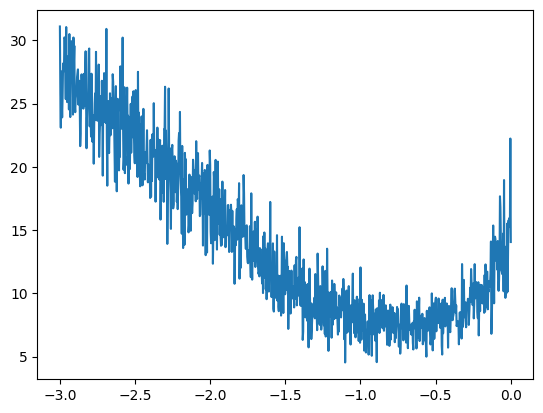

In [14]:
# use mini batch training for tuning for lr
BATCH_SIZE = 32
LEARNING_RATE = tune_for_lr(
    n_experiments=1000,
    low_exp=-3,
    high_exp=0,
    parameters=parameters,
    ds=combined,
    batch_size=BATCH_SIZE
)
LEARNING_RATE

In [15]:
# recreate the parameters now to train just using the train set
EMBED_SIZE = 10
parameters = get_parameters(
    block_size=BLOCK_SIZE,
    embed_size=EMBED_SIZE,
    n_neurons=200,
    seed_val=SEED_VAL,
    vocab=vocab
)

Total Number of parameters : 11897


In [28]:
# train the model
train_model(
    num_epochs=10_000,
    lr = LEARNING_RATE,
    batch_size=BATCH_SIZE,
    ds = train_set,
    parameters=parameters
    
)

loss=2.9464
loss=2.1590
loss=2.3101
loss=2.6278
loss=2.3395
loss=2.1078
loss=2.3629
loss=2.4790
loss=2.3555
loss=2.3932
loss=2.5258
loss=2.6424
loss=1.9952
loss=2.3250
loss=2.5407
loss=1.9963
loss=2.3518
loss=2.3886
loss=2.1571
loss=2.5379
loss=2.2336
loss=2.0927
loss=2.8233
loss=2.2927
loss=2.3319
loss=2.5233
loss=2.2763
loss=2.2502
loss=2.4459
loss=2.1412
loss=2.3188
loss=2.3484
loss=2.2573
loss=2.6752
loss=2.1663
loss=1.9843
loss=2.1736
loss=1.9484
loss=2.2787
loss=2.5674
loss=2.0646
loss=2.6670
loss=2.5190
loss=2.4251
loss=1.9844
loss=2.3471
loss=2.5781
loss=1.9409
loss=2.4132
loss=2.3334
loss=2.4179
loss=2.3140
loss=2.4096
loss=2.4562
loss=2.2190
loss=2.1892
loss=1.8417
loss=2.6713
loss=2.3092
loss=2.2301
loss=1.7950
loss=2.2420
loss=2.4851
loss=2.2391
loss=2.0898
loss=2.5463
loss=2.4687
loss=2.0640
loss=2.0054
loss=2.0677
loss=2.4305
loss=2.6463
loss=1.9995
loss=2.4173
loss=2.0731
loss=1.9017
loss=2.3365
loss=1.9183
loss=2.3121
loss=2.1582
loss=2.5195
loss=2.1949
loss=2.5838
loss

In [29]:
calculate_loss(ds = train_set, parameters=parameters)

loss=2.2970


In [30]:
# train with learning rate decay
train_model(
    num_epochs=10_000,
    lr = LEARNING_RATE,
    batch_size=BATCH_SIZE,
    ds = train_set,
    parameters=parameters,
    decay=10
)

loss=2.6576
loss=2.6647
loss=2.7149
loss=2.6407
loss=1.8920
loss=1.9258
loss=2.2943
loss=2.3981
loss=2.3216
loss=2.3806
loss=2.1011
loss=1.9294
loss=1.8255
loss=2.1907
loss=2.1281
loss=2.4180
loss=2.6667
loss=1.9216
loss=1.9305
loss=2.3275
loss=2.0727
loss=2.3292
loss=2.0207
loss=2.3490
loss=2.0348
loss=1.8267
loss=2.5928
loss=2.0459
loss=2.1805
loss=2.3526
loss=2.0069
loss=2.7556
loss=1.7692
loss=1.9318
loss=2.4428
loss=2.1899
loss=2.6829
loss=2.2981
loss=2.4739
loss=2.2327
loss=2.0424
loss=2.3453
loss=1.9473
loss=1.7416
loss=2.2529
loss=2.3617
loss=2.1488
loss=2.4855
loss=1.9575
loss=2.3541
loss=2.0334
loss=2.2435
loss=2.2619
loss=2.3211
loss=2.2770
loss=2.0969
loss=2.1782
loss=2.0475
loss=2.5202
loss=2.1421
loss=1.9594
loss=1.9919
loss=2.7688
loss=2.5332
loss=2.3595
loss=1.9849
loss=2.6096
loss=2.3761
loss=1.7937
loss=1.9142
loss=2.3627
loss=2.2061
loss=2.5247
loss=2.4767
loss=2.3375
loss=2.4777
loss=2.0056
loss=2.4325
loss=2.0065
loss=2.1782
loss=2.1142
loss=2.1062
loss=2.0870
loss

In [31]:
# evaluate loss on train set after training with lr decay
calculate_loss(ds = train_set, parameters=parameters)

loss=2.1774


In [32]:
# evaluate loss on dev set to check for underfitting / overfitting.
calculate_loss(ds = dev_set, parameters=parameters)

loss=2.2026


In [33]:
calculate_loss(ds=test_set, parameters=parameters)

loss=2.2025


## plotting the embedding vector space and sampling

In [34]:
C, *neural_net = parameters
if not C.shape[1] > 2:
    plt.figure(figsize=(8,8))
    plt.scatter(C[:,0].data, C[:, 1].data, s=200)
    for i in range(len(C)):
        plt.text(C[i, 0].item(),C[i, 1].item(), vocab.itos[i], ha="center", va="center", color="white")
    plt.grid("minor");
else:
    print("Can't vis more than 2-d for now")

Can't vis more than 2-d for now


In [36]:
# sample from the model
g = torch.Generator().manual_seed(SEED_VAL)
W1, b1,W2,b2 = neural_net

for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE

    while True:
        # get the embedding
        emb = C[torch.tensor([context])]
        h = torch.tanh((emb.view(len(emb), -1) @ W1) + b1)
        logits = (h @ W2) + b2
        probs = F.softmax(input = logits, dim=1)
        ix = torch.multinomial(probs, replacement=True, generator=g, num_samples=1).item()
        out.append(vocab.itos[ix])
        if ix == vocab.stoi[BOUNDARY_CHAR]:
            break
        context = context[1:] + [ix]
    print(''.join(out))


anugeen.
tis.
marian.
danjuben.
silaylen.
kemarce.
man.
epiara.
den.
dizi.
kence.
jordin.
kalla.
mikonyjah.
cveline.
chalani.
narcelynn.
mar.
tal.
sen.
